### MACHINE LEARNING ASSIGNMENT 10
### Name Harish Panpaliya
### Branch and Division: CSAI-D
### Roll no: 52

Assignment on Classification technique. Every year many students give the GRE exam to get admission in foreign Universities. The data set contains GRE Scores (out of 340), TOEFL Scores (out of 120), University Rating (out of 5), Statement of Purpose strength (out of 5), Letter of Recommendation strength (out of 5), Undergraduate GPA (out of 10), Research Experience (0=no, 1=yes), Admitted (0=no, 1=yes). Admitted is the target variable.


The counsellor of the firm is supposed check whether the student will get an admission or not based on his/her GRE score and Academic Score. So to help the counsellor to make appropriate decisions, build a machine learning model classifier using a Decision tree to predict whether a student will get admission or not.  Apply Data pre-processing (Label Encoding, Data Transformation….) techniques if necessary.

1. Perform data-preparation (Train-Test Split)
2. Apply Machine Learning Algorithm
3. Evaluate Model.

Dataset: https://www.kaggle.com/mohansacharya/graduate-admissions

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the dataset
df = pd.read_csv('Admission_Predict_Ver1.1.csv')

# Display the first 5 rows
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
# 1. Clean column names (removing leading/trailing spaces)
df.columns = df.columns.str.strip()

# 2. Transform 'Chance of Admit' into a binary 'Admitted' variable
# We use a threshold of 0.7: 1 if Chance >= 0.7, else 0
df['Admitted'] = (df['Chance of Admit'] >= 0.7).astype(int)

# 3. Drop unnecessary columns
# 'Serial No.' is an identifier and 'Chance of Admit' is the old target
df_clean = df.drop(['Serial No.', 'Chance of Admit'], axis=1)

# Check the distribution of the new target variable
print(df_clean['Admitted'].value_counts())
df_clean.head()

Admitted
1    300
0    200
Name: count, dtype: int64


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Admitted
0,337,118,4,4.5,4.5,9.65,1,1
1,324,107,4,4.0,4.5,8.87,1,1
2,316,104,3,3.0,3.5,8.00,1,1
3,322,110,3,3.5,2.5,8.67,1,1
4,314,103,2,2.0,3.0,8.21,0,0


 # Train-Test Split

In [ ]:
# Define Features (X) and Target (y)
X = df_clean.drop('Admitted', axis=1)
y = df_clean['Admitted']

# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (400, 7)
Testing set size: (100, 7)


# Decision Tree

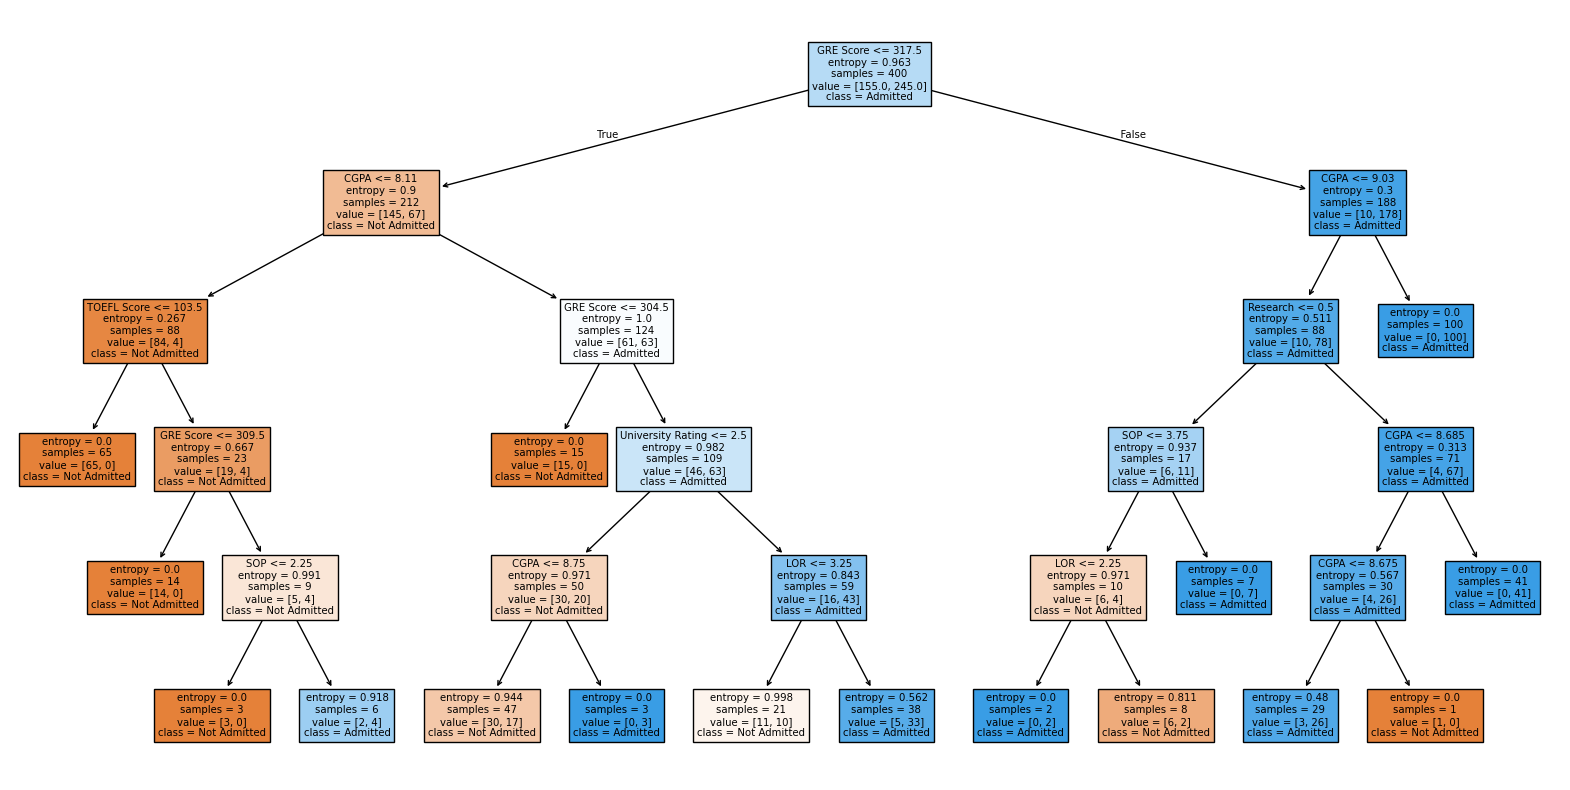

In [ ]:
# Initialize the Classifier
dt_classifier = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train)

# Optional: Visualize the tree structure
plt.figure(figsize=(20,10))
plot_tree(dt_classifier, feature_names=X.columns, class_names=['Not Admitted', 'Admitted'], filled=True)
plt.show()

# Model Evaluation

Overall Accuracy: 82.00%

Confusion Matrix:


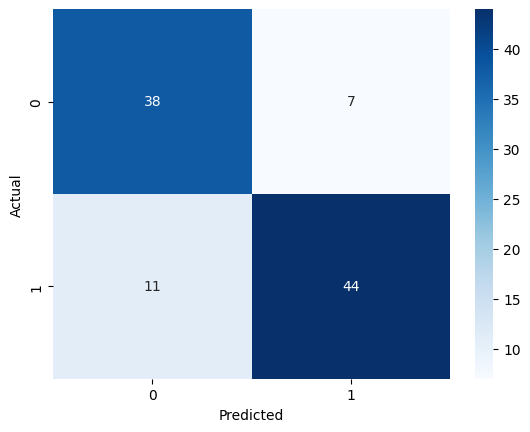


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        45
           1       0.86      0.80      0.83        55

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100



In [ ]:
# Make predictions
y_pred = dt_classifier.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))